In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv")
test = pd.read_csv('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv')
train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [3]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [4]:
train.shape, test.shape

((6818, 13), (1705, 12))

In [5]:
#fill the nan of weight with median 
median_weight = train["product_weight_kg"].median()

train["product_weight_kg"] = train["product_weight_kg"].fillna(median_weight)
test["product_weight_kg"] = test["product_weight_kg"].fillna(median_weight)

train.head()


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,12.647,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [6]:
# replacing the nan in store size with the mode one
train['store_size'] = train["store_size"].fillna(train["store_size"].mode()[0])
test['store_size'] = test["store_size"].fillna(train["store_size"].mode()[0])

In [7]:
train.groupby("store_code")["store_size"].nunique()

store_code
STORE-7WS    1
STORE-89Z    1
STORE-9RG    1
STORE-AGY    1
STORE-DKU    1
STORE-HL7    1
STORE-JOR    1
STORE-OYG    1
STORE-T5G    1
STORE-YLW    1
Name: store_size, dtype: int64

In [8]:
train.isna().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [9]:
test.isna().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
dtype: int64

In [10]:
#investigating the largest total sales
train["total_sales"].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

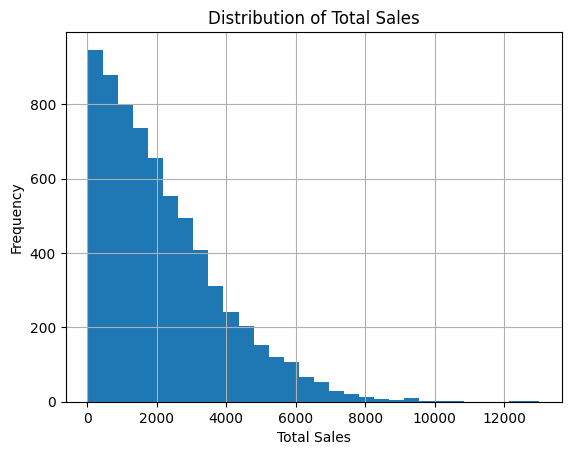

In [11]:
import matplotlib.pyplot as plt

train["total_sales"].hist(bins=30)
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales")
plt.show()

In [12]:
# checking extreme sales value
train["total_sales"].sort_values(ascending=False).head(10)

5404    12996.82
4220    12359.04
235     10477.97
900     10130.90
5950     9999.51
2053     9803.38
5522     9768.51
2825     9564.04
3673     9537.99
745      9523.15
Name: total_sales, dtype: float64

In [13]:
#checking the numeric columns 
train.select_dtypes(include="number").columns

Index(['product_weight_kg', 'shelf_visibility', 'product_price',
       'store_age_years', 'total_sales'],
      dtype='object')

In [14]:
#Examine the correllation 
train.select_dtypes(include="number").corr()["total_sales"].sort_values()

shelf_visibility    -0.118124
product_weight_kg    0.011367
store_age_years      0.039443
product_price        0.569833
total_sales          1.000000
Name: total_sales, dtype: float64

In [15]:
#product category
train["product_category"].value_counts()

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
soft drinks               88
meat                      88
Others                    73
Starchy Foods             

In [16]:
train['product_category'] = train['product_category'].str.title()

train.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,12.647,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


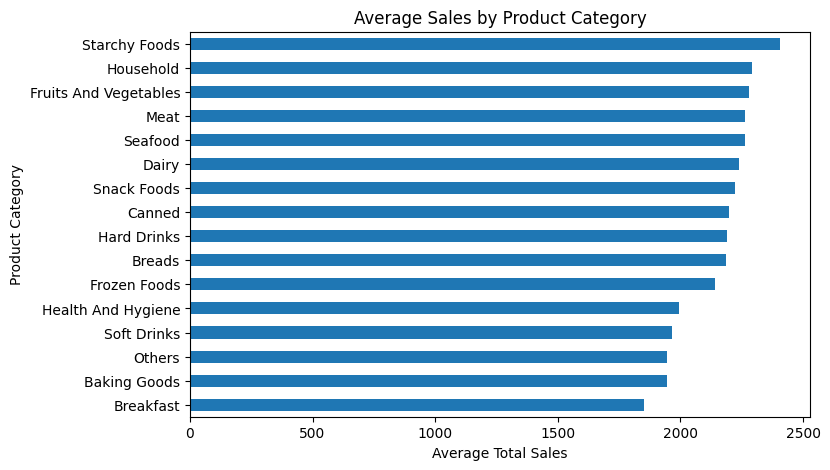

In [17]:
train.groupby("product_category")["total_sales"].mean().sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Average Total Sales")
plt.ylabel("Product Category")
plt.title("Average Sales by Product Category")
plt.show()

In [18]:
# Store location 
train["store_location_tier"].value_counts()

store_location_tier
Tier_3    2677
Tier_2    2232
Tier_1    1909
Name: count, dtype: int64

In [19]:
train.groupby("store_location_tier")["total_sales"].mean().sort_values(ascending=False)

store_location_tier
Tier_2    2341.795296
Tier_3    2254.114400
Tier_1    1868.171278
Name: total_sales, dtype: float64

In [20]:
#store format
train["store_format"].value_counts()

store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

In [21]:
train.groupby("store_format")["total_sales"].mean().sort_values(ascending=False)

store_format
Flagship Hypermarket    3660.182219
Standard Supermarket    2316.319677
Superstore              1971.661954
Corner Shop              336.353868
Name: total_sales, dtype: float64

In [22]:
# Store size 
train["store_size"].value_counts()

store_size
Medium    4137
Small     1933
Large      748
Name: count, dtype: int64

In [23]:
train.groupby("store_size")["total_sales"].mean().sort_values(ascending=False)

store_size
Medium    2280.046846
Large     2254.890120
Small     1918.405954
Name: total_sales, dtype: float64

In [24]:
# Fat content
train["fat_content"].value_counts()

fat_content
Low Fat    4425
Regular    2393
Name: count, dtype: int64

In [25]:
train.groupby("fat_content")["total_sales"].mean().sort_values(ascending=False)

fat_content
Regular    2218.379323
Low Fat    2151.165785
Name: total_sales, dtype: float64

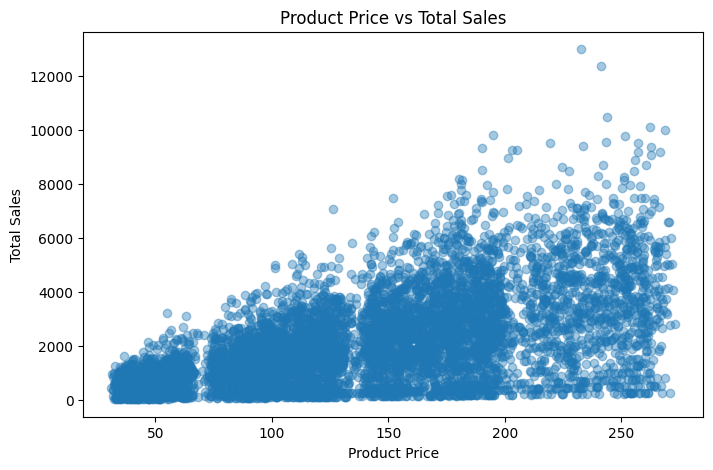

In [26]:
# visualizr product price vs sales
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    train["product_price"],
    train["total_sales"],
    alpha=0.4
)

plt.xlabel("Product Price")
plt.ylabel("Total Sales")
plt.title("Product Price vs Total Sales")

plt.show()

In [27]:
# Checking product visibility
train.groupby("shelf_visibility")["total_sales"].mean().sort_values(ascending=False)

shelf_visibility
0.1444    8726.50
0.0970    7813.00
0.0957    7184.38
0.1599    6839.23
0.1146    6678.96
           ...   
0.2826      46.46
0.2461      44.72
0.1920      44.42
0.2154      39.63
0.2853      34.56
Name: total_sales, Length: 1732, dtype: float64

# Training the dataset

In [28]:
X = train.drop(columns=["total_sales", "id"])
y = train["total_sales"]

In [29]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
Numerical: ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# Encode categorical variable
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [32]:
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)

('cat',
 OneHotEncoder(handle_unknown='ignore'),
 Index(['product_code', 'fat_content', 'product_category', 'store_code',
        'store_size', 'store_location_tier', 'store_format'],
       dtype='object'))

In [33]:
# bulding the first model using random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [34]:
# Then let's train
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['product_weight_kg', 'shelf_visibility', 'product_price',
       'store_age_years'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['product_code', 'fat_content', 'product_category', 'store_code',
       'store_size', 'store_location_tier', 'store_format'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [35]:
# Make validation prediction
y_pred = model.predict(X_valid)

In [36]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_valid, y_pred)

print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 1127.43


In [37]:
# train using catboost too
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

In [38]:
#train
gbr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  Index(['product_weight_kg', 'shelf_visibility', 'product_price',
       'store_age_years'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['product_code', 'fat_content', 'product_category', 'store_code',
       'store_size', 'store_location_tier', 'store_format'],
      dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [39]:
#predict
gbr_pred = gbr_model.predict(X_valid)

In [40]:
# calculate RMSE
from sklearn.metrics import mean_squared_error
gbr_rmse = np.sqrt(
    mean_squared_error(y_valid, gbr_pred)
)

print(f"Gradient Boosting RMSE: {gbr_rmse:,.2f}")

Gradient Boosting RMSE: 1,104.09


In [41]:
x_test = test.drop(columns = ["id"])

In [42]:
test_predictions = model.predict(x_test)

In [43]:
submission = pd.DataFrame({
    'id':test['id'],
    'total_sales':test_predictions
})

In [44]:
submission.head()

,id,total_sales
0,row_00009,2809.030667
1,row_00015,6325.657933
2,row_00019,3247.091600
3,row_00020,3264.166433
4,row_00023,2537.309400


In [45]:
submission.to_csv("submission.csv", index=False)